# Librerias

In [2]:
# Esta es una lista pre hecha con todas las librerias que podria llegar a usar, si sigue este comentario es porque no me dio el tiempo para filtrar las que no usa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import json
import requests
import io, zipfile
from bs4 import BeautifulSoup as bs
import seaborn as sns
import pyarrow.parquet as pq
import geopandas as gpd
import numpy.random as rnd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import sklearn as sk
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from bs4 import BeautifulSoup
from io import StringIO
from dotenv import load_dotenv
import os
import tqdm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px


# Limpieza y transformacion

In [3]:
path = os.path.join("data_2025", "pib2020-2025.csv")
pib = pd.read_csv(path)
pib.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [4]:
pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [5]:
pib[pib.duplicated()]

,Country,2020,2021,2022,2023,2024,2025


In [6]:
pib.dropna()

,Country,2020,2021,2022,2023,2024,2025
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
5,Antigua and Barbuda,1412,1602.0,1867.0,2006.0,2225.0,2373.0
...,...,...,...,...,...,...,...
190,Venezuela,42838,56615.0,89013.0,102377.0,119808.0,108511.0
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0


In [7]:
path = os.path.join("data_2025", "WHO_life_expectancy.csv")
lifeEx = pd.read_csv(path)
lifeEx.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6 [50.7-52.8]
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7 [50.6-53.1]


In [8]:


lifeEx["Value"] = lifeEx["Value"].str.extract("(\d+\.?\d*)")
lifeEx["Value"] = lifeEx["Value"].astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\crist\AppData\Local\Temp\ipykernel_9052\1372410674.py:1: SyntaxWarning: invalid escape sequence '\d'
  lifeEx["Value"] = lifeEx["Value"].str.extract("(\d+\.?\d*)")


In [9]:
lifeEx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IndicatorCode        24420 non-null  object 
 1   Indicator            24420 non-null  object 
 2   ParentLocationCode   24420 non-null  object 
 3   ParentLocation       24420 non-null  object 
 4   Location type        24420 non-null  object 
 5   SpatialDimValueCode  24420 non-null  object 
 6   Location             24420 non-null  object 
 7   Period type          24420 non-null  object 
 8   Period               24420 non-null  int64  
 9   Dim1 type            24420 non-null  object 
 10  Dim1                 24420 non-null  object 
 11  Value                24420 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 2.2+ MB


In [10]:
lifeEx[lifeEx.duplicated()]

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value


In [11]:
lifeEx.columns

Index(['IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation',
       'Location type', 'SpatialDimValueCode', 'Location', 'Period type',
       'Period', 'Dim1 type', 'Dim1', 'Value'],
      dtype='object')

In [12]:
lifeEx["Country"] = lifeEx["Location"]
columnas_interesadas = lifeEx[["Country",'IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location', 'Period type', 'Period', 'Dim1 type', 'Dim1', 'Value']]
pib_merged = pib.merge(columnas_interesadas,  how='left', left_on='Country', right_on='Country')
pib_merged

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021.0,Sex,Male,57.4
1,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021.0,Sex,Both sexes,59.1
2,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021.0,Sex,Female,61.0
3,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000015,Life expectancy at age 60 (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021.0,Sex,Male,13.6
4,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN,WHOSIS_000015,Life expectancy at age 60 (years),EMR,Eastern Mediterranean,Country,AFG,Afghanistan,Year,2021.0,Sex,Both sexes,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21282,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000.0,Sex,Both sexes,45.7
21283,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000.0,Sex,Female,46.7
21284,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000.0,Sex,Male,11.9
21285,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,ZWE,Zimbabwe,Year,2000.0,Sex,Both sexes,13.6


In [13]:
pib.columns

Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')

In [14]:
lifeEx["Country"] = lifeEx["Location"]
columnas_interesadas = pib[['Country', '2020', '2021', '2022', '2023', '2024', '2025']]
lifeEx_merged = lifeEx.merge(columnas_interesadas,  how='left', left_on='Country', right_on='Country')
lifeEx_merged

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Country,2020,2021,2022,2023,2024,2025
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7,Lesotho,2092.0,2445.0,2275.0,2213.0,2309.0,2404.0
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6,Central African Republic,2389.0,2585.0,2460.0,2602.0,2831.0,2932.0
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5,Lesotho,2092.0,2445.0,2275.0,2213.0,2309.0,2404.0
3,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Male,51.6,Eswatini,3984.0,4851.0,4791.0,4858.0,5199.0,5483.0
4,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Male,51.7,Somalia,8628.0,9484.0,10203.0,10969.0,12134.0,12994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24415,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,CHE,Switzerland,Year,2000,Sex,Female,24.8,Switzerland,741288.0,814699.0,828522.0,894867.0,936738.0,947125.0
24416,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,Country,AUS,Australia,Year,2000,Sex,Female,24.9,Australia,1362613.0,1655843.0,1725461.0,1742461.0,1796805.0,1771681.0
24417,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,FRA,France,Year,2000,Sex,Female,25.3,France,2645806.0,2968405.0,2797049.0,3056880.0,3162023.0,3211292.0
24418,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,NIC,Nicaragua,Year,2000,Sex,Female,25.6,Nicaragua,12730.0,14208.0,15634.0,17820.0,19710.0,21155.0


# EDA

<Axes: >

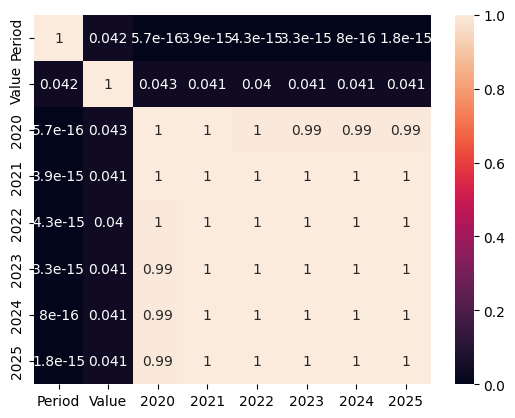

In [15]:
corr = lifeEx_merged.corr(numeric_only=True)


sns.heatmap(corr, annot=True)

In [16]:
lifeEx_merged.sample()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Country,2020,2021,2022,2023,2024,2025
5590,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,NER,Niger,Year,2016,Sex,Both sexes,59.8,Niger,13764.0,14923.0,15458.0,16809.0,19866.0,21874.0


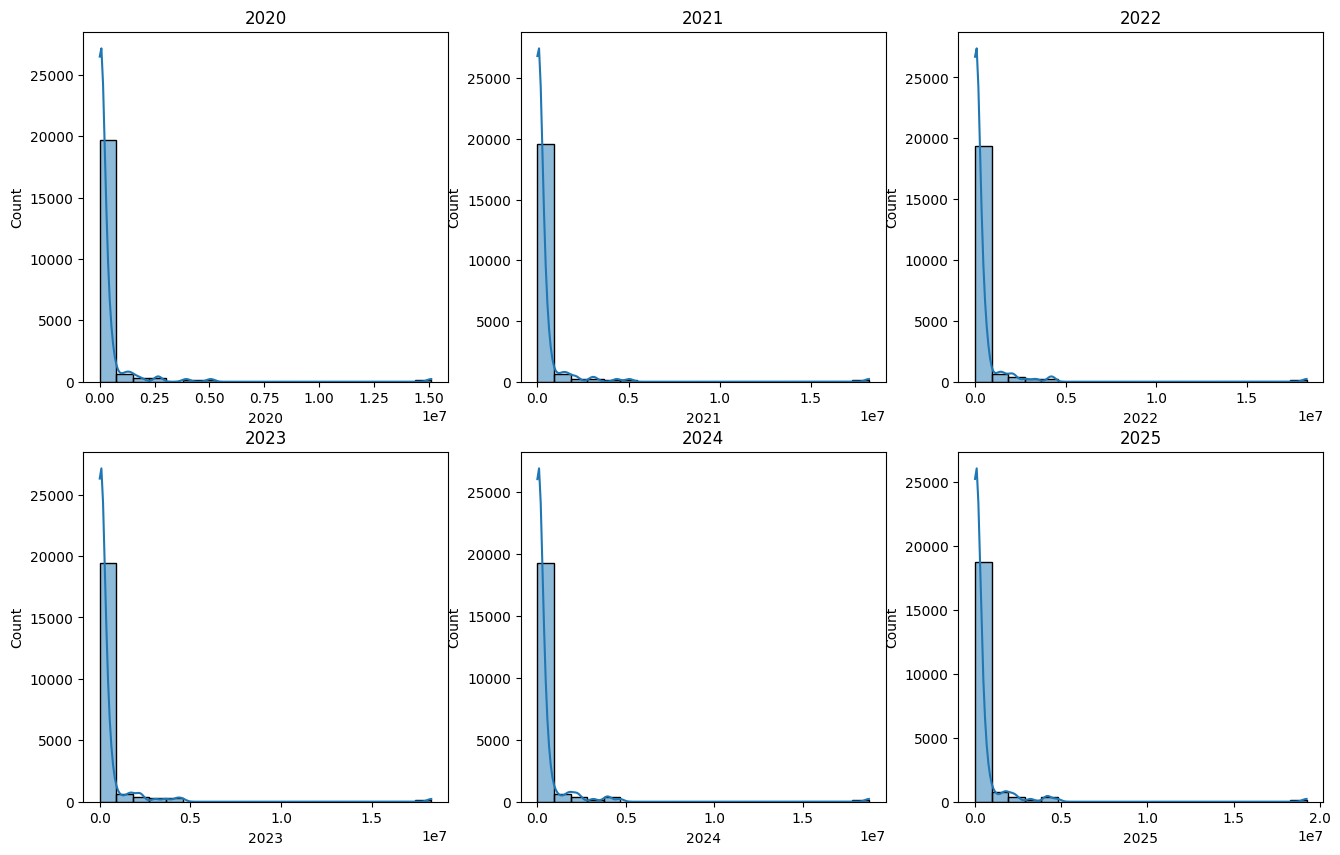

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(16, 10))
    
sns.histplot(data=lifeEx_merged, x='2020', bins=20, kde=True, ax=ax[0, 0])
ax[0, 0].set_title("2020")

sns.histplot(data=lifeEx_merged, x='2021', bins=20, kde=True, ax=ax[0, 1])
ax[0, 1].set_title("2021")

sns.histplot(data=lifeEx_merged, x='2022', bins=20, kde=True, ax=ax[0, 2])
ax[0, 2].set_title("2022")

sns.histplot(data=lifeEx_merged, x='2023', bins=20, kde=True, ax=ax[1, 0])
ax[1, 0].set_title("2023")

sns.histplot(data=lifeEx_merged, x='2024', bins=20, kde=True, ax=ax[1, 1])
ax[1, 1].set_title("2024")

sns.histplot(data=lifeEx_merged, x='2025', bins=20, kde=True, ax=ax[1, 2])
ax[1, 2].set_title("2025")

plt.show()

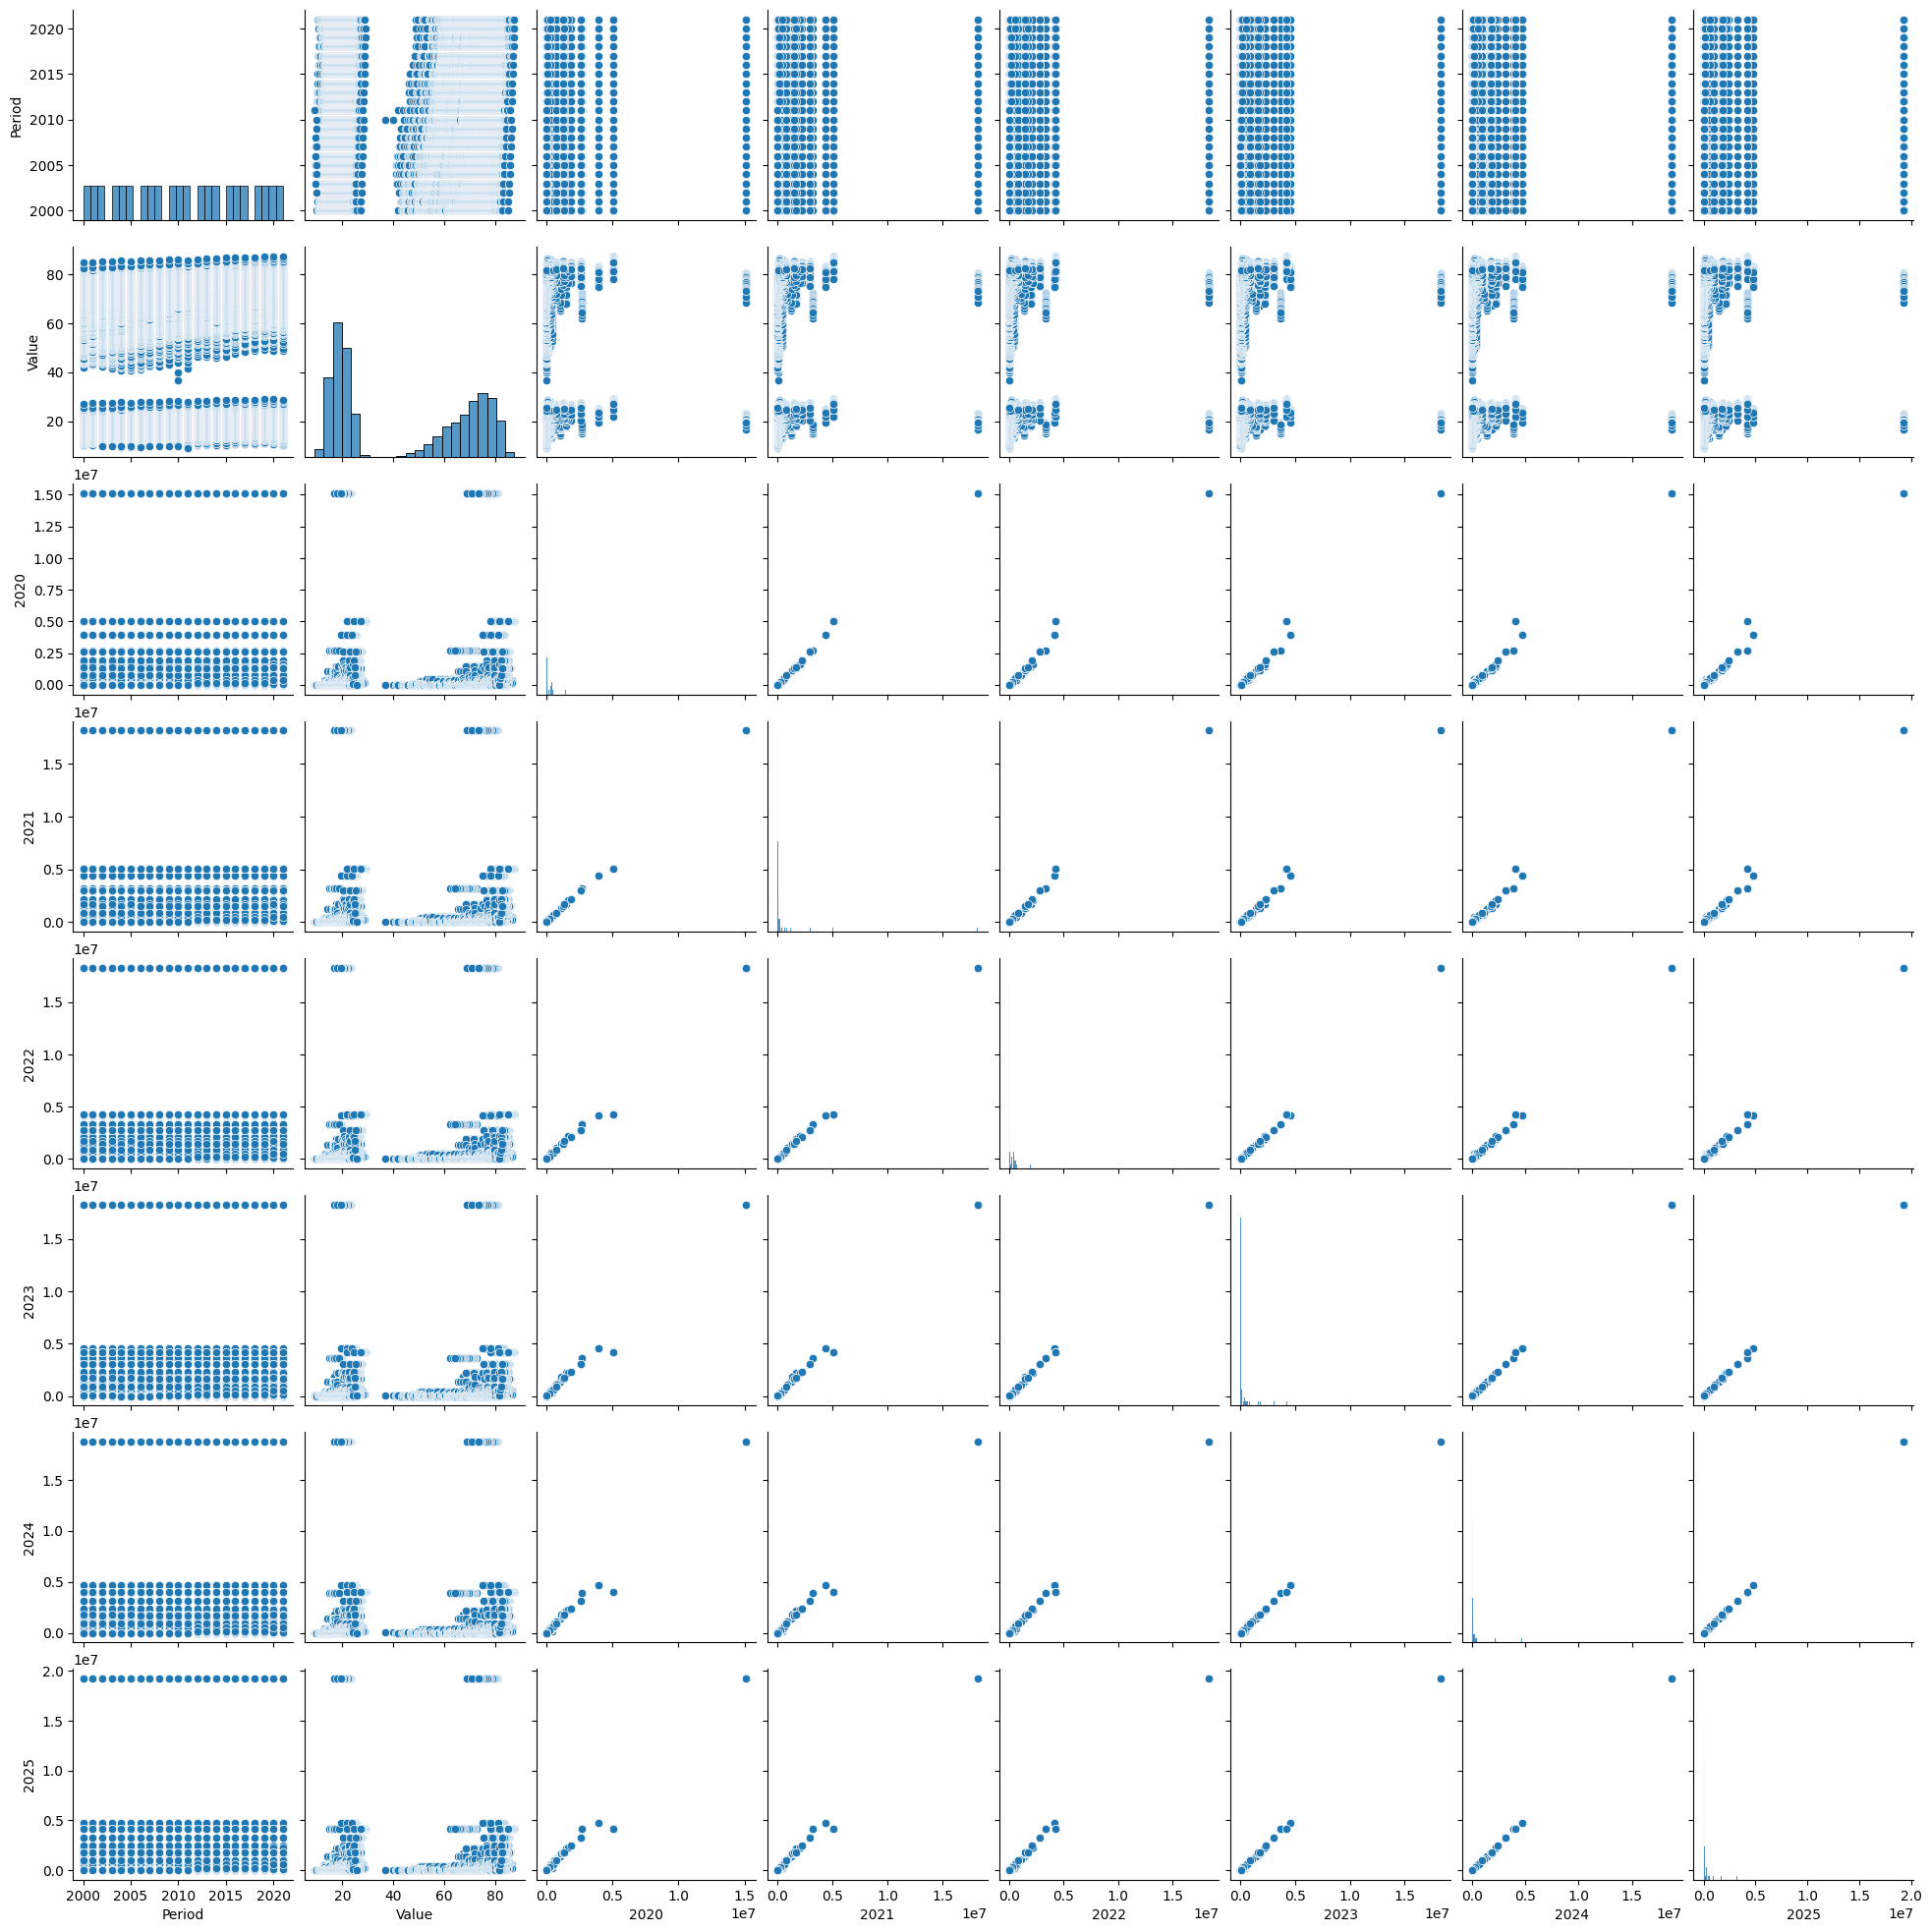

In [18]:
sns.pairplot(lifeEx_merged)

In [19]:
lifeEx_merged.sample(1)

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value,Country,2020,2021,2022,2023,2024,2025
469,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,DNK,Denmark,Year,2021,Sex,Male,79.5,Denmark,355631.0,408378.0,401946.0,407092.0,429458.0,449940.0


# Modelos

In [20]:
lifeEx_merged = pd.get_dummies(lifeEx_merged, columns=['Indicator', "ParentLocation", "Country", "Dim1"], drop_first=True, dtype=int)
lifeEx_merged

,IndicatorCode,ParentLocationCode,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Value,2020,...,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,"Country_occupied Palestinian territory, including east Jerusalem",Dim1_Female,Dim1_Male
0,WHOSIS_000001,AFR,Country,LSO,Lesotho,Year,2021,Sex,48.7,2092.0,...,0,0,0,0,0,0,0,0,0,1
1,WHOSIS_000001,AFR,Country,CAF,Central African Republic,Year,2021,Sex,49.6,2389.0,...,0,0,0,0,0,0,0,0,0,1
2,WHOSIS_000001,AFR,Country,LSO,Lesotho,Year,2021,Sex,51.5,2092.0,...,0,0,0,0,0,0,0,0,0,0
3,WHOSIS_000001,AFR,Country,SWZ,Eswatini,Year,2021,Sex,51.6,3984.0,...,0,0,0,0,0,0,0,0,0,1
4,WHOSIS_000001,EMR,Country,SOM,Somalia,Year,2021,Sex,51.7,8628.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24415,WHOSIS_000015,EUR,Country,CHE,Switzerland,Year,2000,Sex,24.8,741288.0,...,0,0,0,0,0,0,0,0,1,0
24416,WHOSIS_000015,WPR,Country,AUS,Australia,Year,2000,Sex,24.9,1362613.0,...,0,0,0,0,0,0,0,0,1,0
24417,WHOSIS_000015,EUR,Country,FRA,France,Year,2000,Sex,25.3,2645806.0,...,0,0,0,0,0,0,0,0,1,0
24418,WHOSIS_000015,AMR,Country,NIC,Nicaragua,Year,2000,Sex,25.6,12730.0,...,0,0,0,0,0,0,0,0,1,0


## Split Train/Test + Baseline (estadisticas)

In [21]:
col = lifeEx_merged.select_dtypes(include='number').columns.tolist()
lifeEx_merged = lifeEx_merged[col]

In [22]:
lifeEx_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Columns: 200 entries, Period to Dim1_Male
dtypes: float64(7), int64(193)
memory usage: 37.3 MB


In [23]:
lifeEx_merged = lifeEx_merged.dropna()

## Regresión Lineal

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     6398.
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:52:18   Log-Likelihood:                -43146.
No. Observations:               16473   AIC:                         8.661e+04
Df Residuals:                   16313   BIC:                         8.785e+04
Df Model:                         159                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

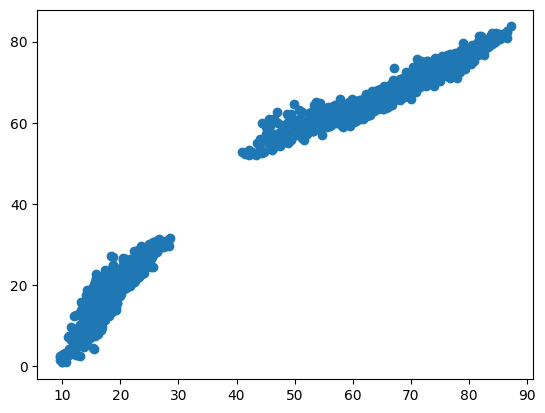

In [24]:
y = lifeEx_merged["Value"]
X = lifeEx_merged.drop(columns=["Value"])

RANDOM_STATE = 42
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

train_X = sm.add_constant(train_X)
test_X = sm.add_constant(test_X)

# modelo OLS (ordinary least squares) entrenado con los datos
regr_sm = sm.OLS(train_y, train_X)

# aplicar fit para entrenar y guardar el modelo
results_sm = regr_sm.fit()

# entregar informacion general del modelo
print(results_sm.summary())

y_fit = results_sm.predict(test_X)


plt.scatter(test_y, y_fit)
